# RUSH Sales Analysis

### Data Collection

In [97]:
import os

folder_path = "./sales_data" # local
csv_files = []

for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        csv_files.append(filename)

print(len(csv_files))
csv_files


3


['TABLE_PRODUCTS_885.csv', 'TABLE_RETAILER_885.csv', 'TABLE_SALES_885.csv']

### Data Preparation

In [98]:
import pandas as pd

dfs = {}

for csv in csv_files:
  file_path = os.path.join(folder_path, csv)
  file_name = os.path.splitext(csv)[0]
  dfs[file_name] = pd.read_csv(file_path)

dfs

{'TABLE_PRODUCTS_885':          PRODUCT_ID|PRODUCT_NAME
 0      020|Men's Street Footwear
 1    030|Men's Athletic Footwear
 2    120|Women's Street Footwear
 3  130|Women's Athletic Footwear
 4              040|Men's Apparel
 5            140|Women's Apparel,
 'TABLE_RETAILER_885':     RETAILER_ID   RETAILER     REGION          STATE            CITY
 0      A00MOHCO     Amazon    Midwest           Ohio        Columbus
 1      A00NMAPO     Amazon  Northeast          Maine        Portland
 2      A00NMABO     Amazon  Northeast  Massachusetts          Boston
 3      A00NNEMA     Amazon  Northeast  New Hampshire      Manchester
 4      A00NVEBU     Amazon  Northeast        Vermont      Burlington
 ..          ...        ...        ...            ...             ...
 105    W00WIDBO  West Gear       West          Idaho           Boise
 106    W00WNELA  West Gear       West         Nevada       Las Vegas
 107    W00WORPO  West Gear       West         Oregon        Portland
 108    W00WUTSA 

### Data Inspection

In [99]:
dfs['TABLE_SALES_885'].head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


In [100]:
dfs['TABLE_SALES_885'].describe()

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,OPERATING_MARGIN
count,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9646.000000,9648.000000
mean,4824.500000,6.458126,14.696310,2020.865050,79.975124,55.575264,0.422991
std,2785.282032,3.454799,7.348019,0.341688,50.668992,1017.819943,0.097197
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.100000
25%,2412.750000,3.000000,9.000000,2021.000000,30.000000,35.000000,0.350000
50%,4824.500000,6.000000,15.000000,2021.000000,40.000000,45.000000,0.410000
75%,7236.250000,9.000000,21.000000,2021.000000,130.000000,55.000000,0.490000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,99999.000000,0.800000


In [101]:
dfs['TABLE_SALES_885'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   str    
 2   INVOICE_DATE      9648 non-null   str    
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   str    
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   str    
dtypes: float64(2), int64(5), str(4)
memory usage: 829.3 KB


In [102]:
dfs['TABLE_RETAILER_885'].head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


Retailer ID contains data according to every other field

In [103]:
dfs['TABLE_RETAILER_885']['RETAILER'].unique()

<StringArray>
['Amazon', 'Foot Locker', 'Kohl's', 'Sports Direct', 'Walmart', 'West Gear']
Length: 6, dtype: str

In [104]:
dfs['TABLE_RETAILER_885'][dfs['TABLE_RETAILER_885']['RETAILER'] == "Kohl's"]

,RETAILER_ID,RETAILER,REGION,STATE,CITY
42,K00MKAWI,Kohl's,Midwest,Kansas,Wichita
43,K00MMIMI,Kohl's,Midwest,Minnesota,Minneapolis
44,K00MMOBI,Kohl's,Midwest,Montana,Billings
45,K00NDEWI,Kohl's,Northeast,Delaware,Wilmington
46,K00NNENE,Kohl's,Northeast,New Jersey,Newark
47,K00NNEAL,Kohl's,Northeast,New York,Albany
48,K00SOKOK,Kohl's,South,Oklahoma,Oklahoma City
49,K00WARPH,Kohl's,West,Arizona,Phoenix
50,K00WCALO,Kohl's,West,California,Los Angeles
51,K00WCASA,Kohl's,West,California,San Francisco


In [105]:
dfs['TABLE_RETAILER_885'].nunique()

RETAILER_ID    106
RETAILER         6
REGION           5
STATE           50
CITY            52
dtype: int64

In [106]:
dfs['TABLE_PRODUCTS_885'].head()

,PRODUCT_ID|PRODUCT_NAME
0,020|Men's Street Footwear
1,030|Men's Athletic Footwear
2,120|Women's Street Footwear
3,130|Women's Athletic Footwear
4,040|Men's Apparel


In [107]:
dfs['TABLE_PRODUCTS_885'].dtypes

PRODUCT_ID|PRODUCT_NAME    str
dtype: object

### Data Cleaning

- Drop redundant data
- Convert data types
- Map product IDs
- Handling outliers
    - Trimming
    - Winsorize
    - Transform
    - Impute


In [108]:
dfs['TABLE_SALES_885'] = dfs['TABLE_SALES_885'].drop_duplicates(
    subset=['ORDER_ID'], 
    keep='first', 
    ignore_index=True
)

In [109]:
dfs['TABLE_SALES_885']['INVOICE_DATE']

0         1/1/2020
1         1/7/2020
2        1/25/2020
3        1/31/2020
4         2/6/2020
           ...    
9643     9/17/2021
9644    10/19/2021
9645    11/18/2021
9646    12/17/2021
9647     1/24/2021
Name: INVOICE_DATE, Length: 9648, dtype: str

In [110]:
full_date_string = (
    dfs["TABLE_SALES_885"]["MONTH"].astype(str)
    + "/"
    + dfs["TABLE_SALES_885"]["DAY"].astype(str)
    + "/"
    + dfs["TABLE_SALES_885"]["YEAR"].astype(str)
)

dfs["TABLE_SALES_885"]["invoice_date_string"] = pd.to_datetime(full_date_string, format="%m/%d/%Y")
dfs["TABLE_SALES_885"]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,invoice_date_string
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.50,In-store,2020-01-01
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.50,In-store,2020-01-07
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.50,Outlet,2020-01-25
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.50,Outlet,2020-01-31
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.50,Outlet,2020-02-06
...,...,...,...,...,...,...,...,...,...,...,...,...
9643,9621,W00WIDBO,9/17/2021,9,17,2021,140,53.0,104,0.37,Outlet,2021-09-17
9644,9627,W00WIDBO,10/19/2021,10,19,2021,140,64.0,90,0.39,Outlet,2021-10-19
9645,9633,W00WIDBO,11/18/2021,11,18,2021,140,61.0,120,0.41,Outlet,2021-11-18
9646,9639,W00WIDBO,12/17/2021,12,17,2021,140,61.0,144,0.40,Outlet,2021-12-17


In [111]:
dfs['TABLE_SALES_885']['INVOICE_DATE_DT'] = pd.to_datetime(dfs['TABLE_SALES_885']['INVOICE_DATE'], format="%m/%d/%Y", errors="coerce")
dfs['TABLE_SALES_885']

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,invoice_date_string,INVOICE_DATE_DT
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.50,In-store,2020-01-01,2020-01-01
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.50,In-store,2020-01-07,2020-01-07
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.50,Outlet,2020-01-25,2020-01-25
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.50,Outlet,2020-01-31,2020-01-31
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.50,Outlet,2020-02-06,2020-02-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,9621,W00WIDBO,9/17/2021,9,17,2021,140,53.0,104,0.37,Outlet,2021-09-17,2021-09-17
9644,9627,W00WIDBO,10/19/2021,10,19,2021,140,64.0,90,0.39,Outlet,2021-10-19,2021-10-19
9645,9633,W00WIDBO,11/18/2021,11,18,2021,140,61.0,120,0.41,Outlet,2021-11-18,2021-11-18
9646,9639,W00WIDBO,12/17/2021,12,17,2021,140,61.0,144,0.40,Outlet,2021-12-17,2021-12-17


In [112]:
date_mismatches = dfs['TABLE_SALES_885']['invoice_date_string'].equals(dfs['TABLE_SALES_885']['INVOICE_DATE_DT']) # None

In [113]:
dfs['TABLE_SALES_885']['INVOICE_DATE_VERIFIED'] = dfs['TABLE_SALES_885']['INVOICE_DATE_DT']

In [114]:
dfs['TABLE_SALES_885'].drop(columns=['INVOICE_DATE', 'MONTH', 'DAY', 'YEAR', 'invoice_date_string', 'INVOICE_DATE_DT'], inplace=True)

In [115]:
dfs['TABLE_SALES_885']['UNITS_SOLD'] = pd.to_numeric(dfs['TABLE_SALES_885']['UNITS_SOLD'], errors='coerce')

In [116]:
dfs['TABLE_SALES_885']['SALES_METHOD'] = dfs['TABLE_SALES_885']['SALES_METHOD'].replace('Ootlet', 'Outlet')

In [117]:
dfs['TABLE_PRODUCTS_885'].head()

,PRODUCT_ID|PRODUCT_NAME
0,020|Men's Street Footwear
1,030|Men's Athletic Footwear
2,120|Women's Street Footwear
3,130|Women's Athletic Footwear
4,040|Men's Apparel


In [118]:
col_name = dfs["TABLE_PRODUCTS_885"].columns[0]

dfs["TABLE_PRODUCTS_885"][["PRODUCT_ID", "PRODUCT_NAME"]] = dfs[
    "TABLE_PRODUCTS_885"
][col_name].str.split("|", expand=True)

dfs["TABLE_PRODUCTS_885"] = dfs["TABLE_PRODUCTS_885"].drop(columns=[col_name])


In [119]:
dfs['TABLE_PRODUCTS_885'].head()

,PRODUCT_ID,PRODUCT_NAME
0,020,Men's Street Footwear
1,030,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,040,Men's Apparel


In [120]:
dfs['TABLE_PRODUCTS_885']['PRODUCT_ID'] = pd.to_numeric(dfs['TABLE_PRODUCTS_885']['PRODUCT_ID'], errors='coerce')

In [121]:
product_map = dict(
    zip(dfs["TABLE_PRODUCTS_885"]["PRODUCT_ID"], dfs["TABLE_PRODUCTS_885"]["PRODUCT_NAME"])
)

Sales:
-  PK: ORDER ID
- FK: RETAILER ID
- FK: PRODUCT ID

In [122]:
df_combined = dfs['TABLE_SALES_885'].merge(dfs['TABLE_RETAILER_885'], on='RETAILER_ID', how='left')

In [123]:
df_combined['PRODUCT_NAME'] = df_combined['PRODUCT_ID'].map(product_map)

In [124]:
df_combined.head(20)

,ORDER_ID,RETAILER_ID,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,INVOICE_DATE_VERIFIED,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
0,1,A00MOHCO,20,50.0,1200.0,0.50,In-store,2020-01-01,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
1,7,A00MOHCO,20,50.0,1250.0,0.50,In-store,2020-01-07,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
2,13,A00MOHCO,20,50.0,1220.0,0.50,Outlet,2020-01-25,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
3,19,A00MOHCO,20,50.0,1200.0,0.50,Outlet,2020-01-31,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
4,25,A00MOHCO,20,60.0,1220.0,0.50,Outlet,2020-02-06,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
5,31,A00MOHCO,20,60.0,1250.0,0.50,Outlet,2020-03-04,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
6,37,A00MOHCO,20,60.0,1275.0,0.50,Outlet,2020-03-10,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
7,43,A00MOHCO,20,60.0,1250.0,0.50,Outlet,2020-03-16,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
8,49,A00MOHCO,20,60.0,1200.0,0.50,Outlet,2020-04-19,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
9,57,A00MOHCO,20,65.0,1150.0,0.50,Outlet,2020-04-27,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear


In [125]:
df_combined.describe()

,ORDER_ID,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,INVOICE_DATE_VERIFIED
count,10271.000000,10271.000000,10269.000000,10269.000000,10271.000000,10271
mean,4970.630903,80.001947,54.575324,246.638232,0.426380,2021-05-13 12:00:54.678220
min,1.000000,20.000000,7.000000,0.000000,0.100000,2020-01-01 00:00:00
25%,2568.500000,30.000000,35.000000,100.000000,0.350000,2021-02-18 00:00:00
50%,5136.000000,120.000000,45.000000,173.000000,0.420000,2021-06-05 00:00:00
75%,7236.000000,130.000000,55.000000,325.000000,0.500000,2021-09-17 00:00:00
max,9648.000000,140.000000,99999.000000,1275.000000,0.800000,2021-12-31 00:00:00
std,2770.737186,50.671441,986.473924,211.881078,0.096018,NaN


In [126]:
error_mask = (df_combined['PRICE_PER_UNIT'].isna()) | (df_combined['PRICE_PER_UNIT'] == 99999.0)
df_clean = df_combined[~error_mask].copy()

In [127]:
# Calculate Q1, Q3, and upper limits per category
q1 = df_clean.groupby('PRODUCT_NAME')['PRICE_PER_UNIT'].quantile(0.25)
q3 = df_clean.groupby('PRODUCT_NAME')['PRICE_PER_UNIT'].quantile(0.75)
upper_limit = q3 + 1.5 * (q3 - q1)

# Map the limits to each row in the dataframe and filter
row_limits = df_clean['PRODUCT_NAME'].map(upper_limit)

# Winsorize by clipping the column between 0 and the mapped limits
df_clean['PRICE_PER_UNIT_winsorized'] = df_clean['PRICE_PER_UNIT'].clip(lower=0, upper=row_limits)

df_clean.head()

,ORDER_ID,RETAILER_ID,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,INVOICE_DATE_VERIFIED,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,PRICE_PER_UNIT_winsorized
0,1,A00MOHCO,20,50.0,1200.0,0.5,In-store,2020-01-01,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0
1,7,A00MOHCO,20,50.0,1250.0,0.5,In-store,2020-01-07,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0
2,13,A00MOHCO,20,50.0,1220.0,0.5,Outlet,2020-01-25,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0
3,19,A00MOHCO,20,50.0,1200.0,0.5,Outlet,2020-01-31,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0
4,25,A00MOHCO,20,60.0,1220.0,0.5,Outlet,2020-02-06,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,60.0


In [128]:
prices_comparison = df_clean[
    (df_clean['PRICE_PER_UNIT'] != df_clean['PRICE_PER_UNIT_winsorized']) & 
    df_clean['PRICE_PER_UNIT'].notna()
]
prices_comparison[['PRODUCT_NAME', 'PRICE_PER_UNIT', 'PRICE_PER_UNIT_winsorized']].head(20)


,PRODUCT_NAME,PRICE_PER_UNIT,PRICE_PER_UNIT_winsorized
233,Men's Street Footwear,90.0,86.5
234,Men's Street Footwear,95.0,86.5
270,Men's Street Footwear,90.0,86.5
318,Men's Street Footwear,90.0,86.5
329,Men's Street Footwear,90.0,86.5
330,Men's Street Footwear,95.0,86.5
883,Men's Street Footwear,87.0,86.5
1825,Men's Athletic Footwear,80.0,75.0
1826,Men's Athletic Footwear,85.0,75.0
1827,Men's Athletic Footwear,80.0,75.0


### Explorations

In [129]:
# Calculate metrics
df_clean['REVENUE'] = df_clean['UNITS_SOLD'] * df_clean['PRICE_PER_UNIT']
df_clean['OPERATING_PROFIT'] = df_clean['REVENUE'] * df_clean['OPERATING_MARGIN']
df_clean['TOTAL_EXPENSES'] = df_clean['REVENUE'] * (1 - df_clean['OPERATING_MARGIN'])
df_clean['UNIT_COST'] = df_clean['PRICE_PER_UNIT'] * (1 - df_clean['OPERATING_MARGIN'])

df_clean.head()


,ORDER_ID,RETAILER_ID,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,INVOICE_DATE_VERIFIED,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,PRICE_PER_UNIT_winsorized,REVENUE,OPERATING_PROFIT,TOTAL_EXPENSES,UNIT_COST
0,1,A00MOHCO,20,50.0,1200.0,0.5,In-store,2020-01-01,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0,60000.0,30000.0,30000.0,25.0
1,7,A00MOHCO,20,50.0,1250.0,0.5,In-store,2020-01-07,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0,62500.0,31250.0,31250.0,25.0
2,13,A00MOHCO,20,50.0,1220.0,0.5,Outlet,2020-01-25,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0,61000.0,30500.0,30500.0,25.0
3,19,A00MOHCO,20,50.0,1200.0,0.5,Outlet,2020-01-31,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,50.0,60000.0,30000.0,30000.0,25.0
4,25,A00MOHCO,20,60.0,1220.0,0.5,Outlet,2020-02-06,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,60.0,73200.0,36600.0,36600.0,30.0


Looking for trends or insights in seasonality, retailers, locations, or sales methods

In [130]:
df_clean['QUARTER'] = df_clean['INVOICE_DATE_VERIFIED'].dt.to_period('Q').astype(str)
df_filtered = df_clean[df_clean['INVOICE_DATE_VERIFIED'].dt.year.isin([2020, 2021])].copy()
df_filtered['YEAR'] = df_filtered['INVOICE_DATE_VERIFIED'].dt.year
quarterly_sales = df_filtered.groupby(['YEAR', 'QUARTER', 'PRODUCT_NAME'])['REVENUE'].sum().reset_index()
quarterly_sales = quarterly_sales.sort_values(by=['YEAR', 'REVENUE'], ascending=[True, False])
quarterly_sales.head()


,YEAR,QUARTER,PRODUCT_NAME,REVENUE
2,2020,2020Q1,Men's Street Footwear,1470386.0
15,2020,2020Q3,Women's Apparel,1427292.0
14,2020,2020Q3,Men's Street Footwear,1360481.0
13,2020,2020Q3,Men's Athletic Footwear,1301146.0
9,2020,2020Q2,Women's Apparel,1296769.0


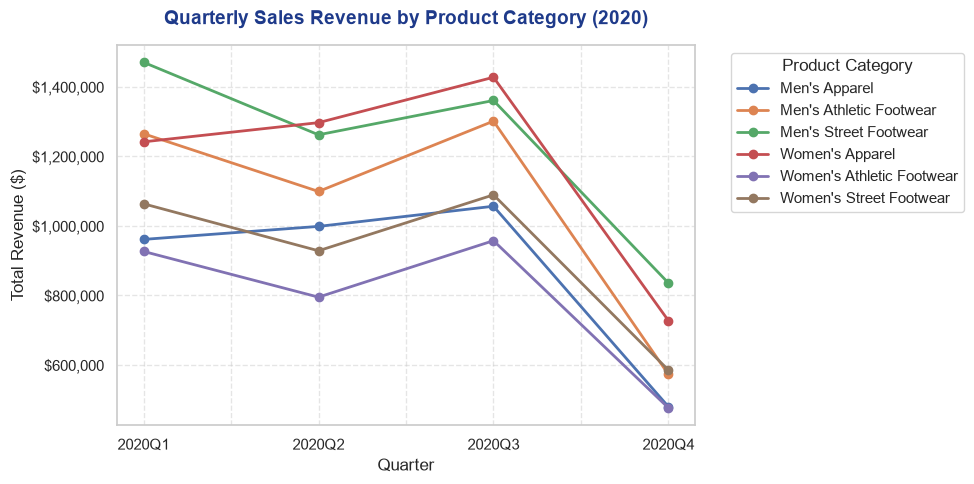

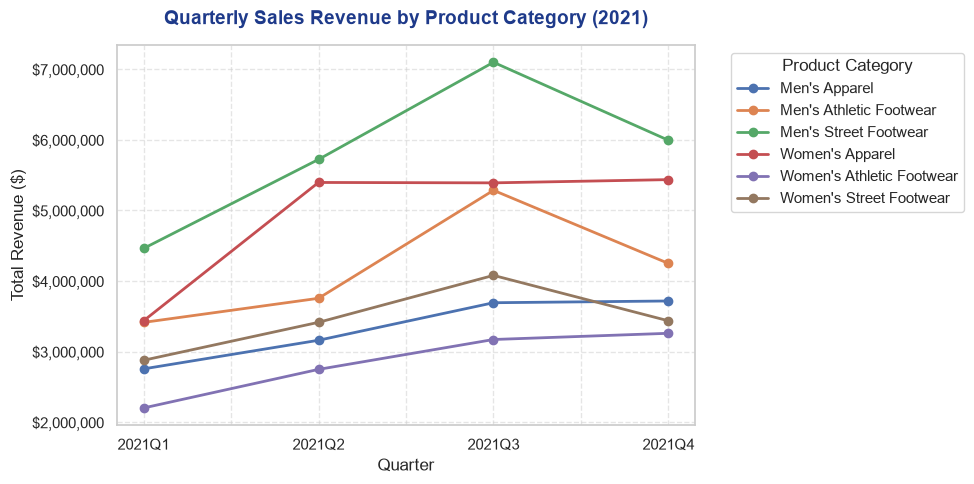

In [131]:
import matplotlib.pyplot as plt

# 1. Pivot the data to have QUARTER as the index and PRODUCT_NAME as columns
quarterly_pivot = quarterly_sales.pivot(index='QUARTER', columns='PRODUCT_NAME', values='REVENUE').sort_index()

# 2. Loop through years to generate multiple plots dynamically
years = sorted(list(set(quarterly_sales['YEAR'].astype(str))))
for year in years:
    # Filter the pivoted DataFrame for the current year
    pivot_year = quarterly_pivot.loc[quarterly_pivot.index.str.startswith(year)]
    
    # Create a separate plot for each year
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot_year.plot(kind='line', marker='o', ax=ax, linewidth=2)
    
    # Customize plot styling
    plt.title(f'Quarterly Sales Revenue by Product Category ({year})', fontsize=14, fontweight='bold', pad=15, color='#1E3A8A')
    plt.xlabel('Quarter', fontsize=12)
    plt.ylabel('Total Revenue ($)', fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

In [132]:
retailer_summary = df_clean.groupby('RETAILER').agg(
    Units_Sold=('UNITS_SOLD', 'sum'),
    Total_Revenue=('REVENUE', 'sum'),
    Total_Profit=('OPERATING_PROFIT', 'sum'),
    Average_Margin=('OPERATING_MARGIN', 'mean')
).sort_values(by='Total_Revenue', ascending=False).reset_index()

retailer_summary

,RETAILER,Units_Sold,Total_Revenue,Total_Profit,Average_Margin
0,Foot Locker,1096890.0,53620425.0,20031338.75,0.367356
1,Amazon,522450.0,27962625.0,9835765.00,0.357392
2,West Gear,372836.0,14584306.0,6278475.11,0.435817
3,Sports Direct,274762.0,13031410.0,6529054.58,0.496944
4,Kohl's,205636.0,10852813.0,4511587.01,0.436816
5,Walmart,58286.0,2256523.0,1085353.17,0.475141


In [133]:
region_product_pivot = df_clean.pivot_table(
    values='REVENUE', 
    index='REGION', 
    columns='PRODUCT_NAME', 
    aggfunc='sum'
)

region_product_pivot

PRODUCT_NAME,Men's Apparel,Men's Athletic Footwear,Men's Street Footwear,Women's Apparel,Women's Athletic Footwear,Women's Street Footwear
REGION,,,,,,
Midwest,4384375.0,5580881.0,6682909.0,6190790.0,3900005.0,4694610.0
Northeast,5551207.0,6610928.0,8903606.0,7906721.0,4710645.0,5564317.0
South,1543674.0,1934880.0,2905937.0,2332262.0,1268895.0,1464774.0
Southeast,2143389.0,2491072.0,3786014.0,3085072.0,1729721.0,2120868.0
West,3198555.0,4322532.0,5906910.0,4836766.0,2926667.0,3629120.0


In [134]:
import plotly.express as px
import pandas as pd
import us

# 1. Extract the state code from within RETAILER_ID (characters at index 4 and 5)
df_clean['RETAILER_STATE_CODE'] = df_clean['RETAILER_ID'].astype(str).str[4:6]

# 2. Fetch the standard US state abbreviations using the 'us' library, handling NaN/float values safely
df_clean['STANDARD_STATE_CODE'] = df_clean['STATE'].apply(
    lambda x: us.states.lookup(str(x)).abbr if pd.notna(x) and us.states.lookup(str(x)) else None
)

# 3. Create a unique cross-referenced mapping of STATE, REGION, RETAILER_STATE_CODE, and STANDARD_STATE_CODE
state_region_map = df_clean[['STATE', 'REGION', 'RETAILER_STATE_CODE', 'STANDARD_STATE_CODE']].drop_duplicates(subset=['STATE']).copy()

# 4. Calculate total revenue by region from the pivot table
region_revenue = region_product_pivot.sum(axis=1).reset_index()
region_revenue.columns = ['REGION', 'TOTAL_REVENUE']

# 5. Merge state mapping with region revenue totals
state_revenue = state_region_map.merge(region_revenue, on='REGION', how='left')

# 6. Plot US Choropleth Map using Plotly Express using the standard code
fig = px.choropleth(
    state_revenue,
    locations='STANDARD_STATE_CODE',
    locationmode='USA-states',
    color='TOTAL_REVENUE',
    scope='usa',
    color_continuous_scale='Blues',  # Filled in shades of blue
    title='US Revenue Distribution by Region (State-Level Mapping)',
    labels={'TOTAL_REVENUE': 'Total Revenue ($)', 'STANDARD_STATE_CODE': 'State Code'}
)

# Customize title layout
fig.update_layout(
    title_font_size=16,
    title_font_color='#1E3A8A',
    title_font_family='Arial',
    title_x=0.5,
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0}
)

fig.show()

In [135]:
channel_analysis = df_clean.groupby('SALES_METHOD').agg(
    Total_Revenue=('REVENUE', 'sum'),
    Units_Sold=('UNITS_SOLD', 'sum'),
    Average_Margin=('OPERATING_MARGIN', 'mean'),
    Total_Profit=('OPERATING_PROFIT', 'sum')
).reset_index()

channel_analysis

,SALES_METHOD,Total_Revenue,Units_Sold,Average_Margin,Total_Profit
0,In-store,35601375.0,688940.0,0.356041,12732353.75
1,Online,46942252.0,983961.0,0.466632,20529852.90
2,Outlet,39782355.0,858257.0,0.395639,15016876.57


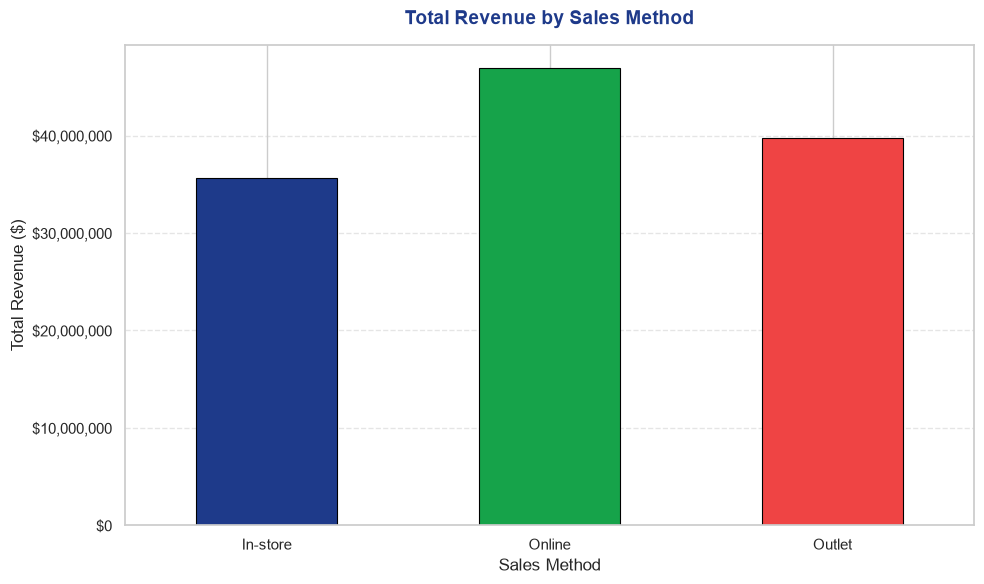

In [136]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Color mapping: In-store (Blue), Online (Green), Outlet (Red)
channel_colors = ["#1E3A8A", "#16A34A", "#EF4444"]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
channel_analysis.set_index('SALES_METHOD')['Total_Revenue'].plot(
    kind='bar',
    ax=ax,
    color=channel_colors,
    edgecolor='black',
    linewidth=0.8
)
plt.title('Total Revenue by Sales Method', fontsize=14, fontweight='bold', pad=15, color='#1E3A8A')
plt.xlabel('Sales Method', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.0f}".format(x)))
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Analysis

##### Metrics

| Metric | Formula |
| :--- | :--- |
| **Revenue** | $\text{Units Sold} \times \text{Price per Unit}$ |
| **Operating Profit** | $\text{Revenue} \times \text{Operating Margin}$ |
| **Total Expenses** | $\text{Revenue} \times (1 - \text{Operating Margin})$ |
| **Unit Cost** | $\text{Price per Unit} \times (1 - \text{Operating Margin})$ |


In [137]:
# Summary statistics of the calculated metrics
df_clean[['REVENUE', 'OPERATING_PROFIT', 'TOTAL_EXPENSES', 'UNIT_COST']].describe()


,REVENUE,OPERATING_PROFIT,TOTAL_EXPENSES,UNIT_COST
count,10266.000000,10266.000000,10266.000000,10268.000000
mean,11915.642120,4702.813483,7212.828636,25.920040
std,12523.379834,4788.164047,8208.537503,10.444515
min,0.000000,0.000000,0.000000,3.690000
25%,3750.000000,1639.215000,1985.647500,18.550000
50%,7304.000000,3078.015000,3959.280000,24.500000
75%,15000.000000,5938.475000,9100.000000,31.860000
max,82500.000000,39000.000000,56700.000000,80.000000


### Business Questions

- What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
- What state had the highest sales (in dollars) of women's products in 2021? How much was it?
- What state had the highest sales (in dollars) of men's products in 2021? How much was it?
- What retailer purchased the most units in 2021? In 2020?

In [138]:
def analyze_sales(df, years, date_col='INVOICE_DATE_VERIFIED', product_col='PRODUCT_NAME', product_filter=None, group_col=None, metric_col='REVENUE'):

    df = df[df[date_col].dt.year.isin(years)].copy()
    
    # Filter by product keyword if provided
    if product_filter and product_col:
        df = df[df[product_col].str.contains(rf'\b{product_filter}\b', case=False, na=False)]
    
    # Create year column for grouping
    df['YEAR'] = df[date_col].dt.year
    
    # Group by YEAR and group_col
    group_cols = ['YEAR']
    if group_col:
        if isinstance(group_col, list):
            group_cols.extend(group_col)
        else:
            group_cols.append(group_col)
            
    # Aggregate sum of target metric
    sales = df.groupby(group_cols)[metric_col].sum().reset_index()
    
    # Sort by YEAR ascending, and then by metric_col descending
    return sales.sort_values(by=['YEAR', metric_col], ascending=[True, False])

In [139]:
highest_product_sales_2021 = analyze_sales(df_clean, years=[2021], product_filter=None, group_col='PRODUCT_NAME')
highest_product_sales_2021

,YEAR,PRODUCT_NAME,REVENUE
2,2021,Men's Street Footwear,23275236.0
3,2021,Women's Apparel,19658904.0
1,2021,Men's Athletic Footwear,16702706.0
5,2021,Women's Street Footwear,13807909.0
0,2021,Men's Apparel,13325861.0
4,2021,Women's Athletic Footwear,11381041.0


C:\Users\tjr\AppData\Local\Temp\ipykernel_24948\2518989029.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


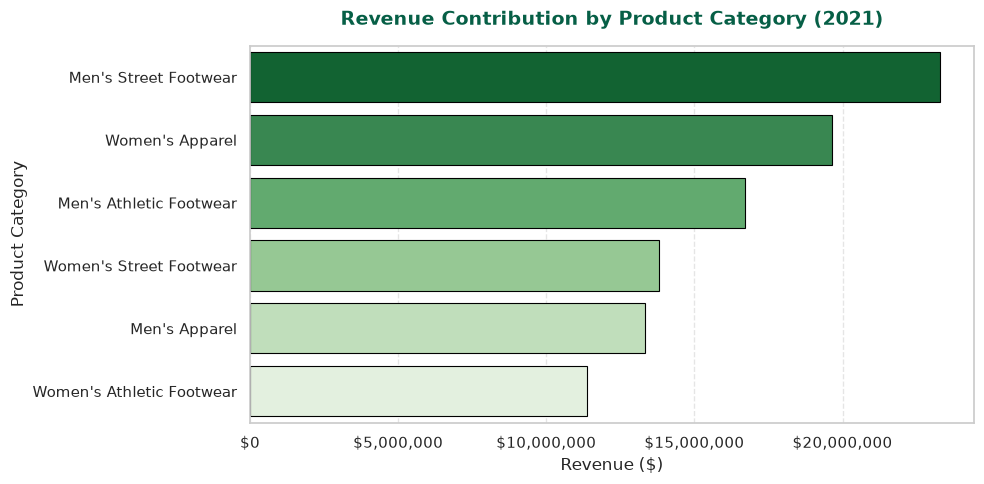

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# Sort categories for horizontal plotting
highest_sales_sorted = highest_product_sales_2021.sort_values(by='REVENUE', ascending=False)

# Custom sequential green palette (dark green to light green)
custom_greens = sns.color_palette("Greens_r", n_colors=len(highest_sales_sorted))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=highest_sales_sorted, 
    x='REVENUE', 
    y='PRODUCT_NAME', 
    palette=custom_greens, 
    edgecolor='black',
    linewidth=0.8
)
plt.title('Revenue Contribution by Product Category (2021)', fontsize=14, fontweight='bold', pad=15, color='#065F46')
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.0f}".format(x)))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [141]:
highest_women_sales_state = analyze_sales(df_clean, years=[2021], product_filter='women', group_col='STATE')
highest_women_sales_state.head()

,YEAR,STATE,REVENUE
18,2021,Maine,2176301.0
7,2021,Delaware,2023575.0
28,2021,New Hampshire,1916400.0
2,2021,Arizona,1798900.0
24,2021,Missouri,1771992.0


In [142]:
highest_men_sales_state = analyze_sales(df_clean, years=[2021], product_filter='men', group_col='STATE')
highest_men_sales_state.head()

,YEAR,STATE,REVENUE
7,2021,Delaware,2334300.0
2,2021,Arizona,2261025.0
18,2021,Maine,2217190.0
28,2021,New Hampshire,2208600.0
31,2021,New York,2114999.0


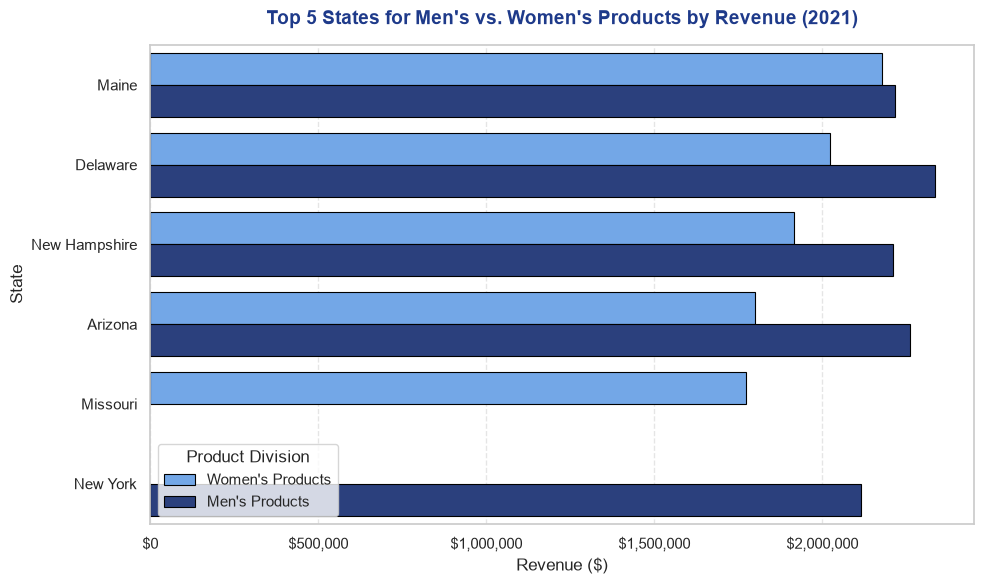

In [143]:
# Set style
sns.set_theme(style="whitegrid")

# Add temporary category labels to distinguish groups
highest_women_sales_state['Gender'] = "Women's Products"
highest_men_sales_state['Gender'] = "Men's Products"

# Combine top 5 states from both datasets
top_states_combined = pd.concat([
    highest_women_sales_state.head(5),
    highest_men_sales_state.head(5)
])

# Cohesive blue palette for comparison
blue_comparison_palette = {"Men's Products": "#1E3A8A", "Women's Products": "#60A5FA"}

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_states_combined,
    x='REVENUE',
    y='STATE',
    hue='Gender',
    palette=blue_comparison_palette,
    edgecolor='black',
    linewidth=0.8
)
plt.title("Top 5 States for Men's vs. Women's Products by Revenue (2021)", fontsize=14, fontweight='bold', pad=15, color='#1E3A8A')
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.0f}".format(x)))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Product Division')

plt.tight_layout()
plt.show()

New York Mens missing

In [144]:
highest_retailer_purchases = analyze_sales(
    df_clean, 
    years=[2020, 2021], 
    product_filter=None, 
    group_col='RETAILER', 
    metric_col='UNITS_SOLD'
)
highest_retailer_purchases

,YEAR,RETAILER,UNITS_SOLD
0,2020,Amazon,316880.0
1,2020,Kohl's,68686.0
3,2020,West Gear,57334.0
2,2020,Sports Direct,18399.0
5,2021,Foot Locker,1096890.0
9,2021,West Gear,315502.0
7,2021,Sports Direct,256363.0
4,2021,Amazon,205570.0
6,2021,Kohl's,136950.0
8,2021,Walmart,58286.0


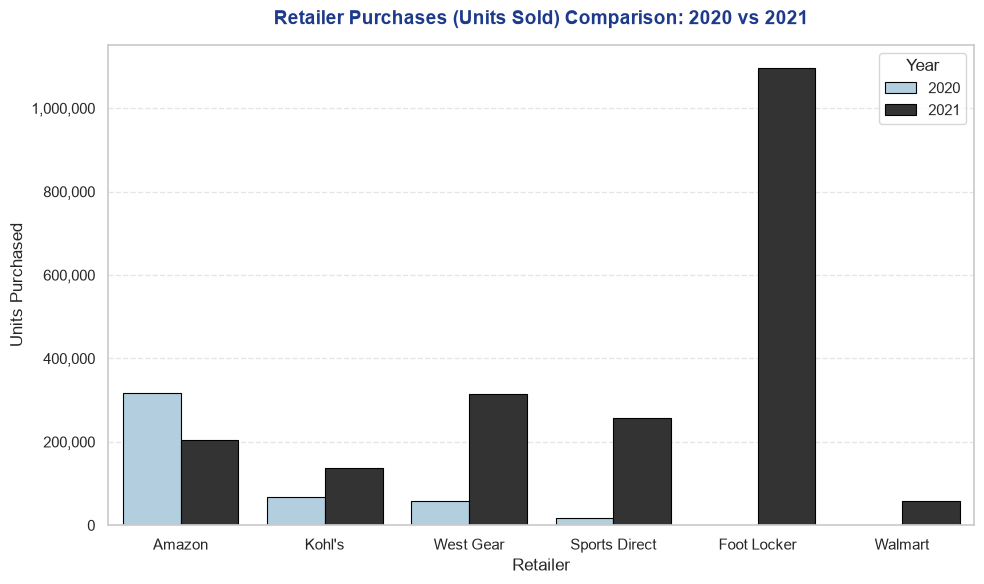

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot a grouped bar chart to compare retailer purchases (Units Sold) in 2020 vs 2021
plt.figure(figsize=(10, 6))
sns.barplot(
    data=highest_retailer_purchases,
    x='RETAILER',
    y='UNITS_SOLD',
    hue='YEAR',
    palette='Blues_d',
    edgecolor='black',
    linewidth=0.8
)

plt.title('Retailer Purchases (Units Sold) Comparison: 2020 vs 2021', fontsize=14, fontweight='bold', pad=15, color='#1E3A8A')
plt.xlabel('Retailer', fontsize=12)
plt.ylabel('Units Purchased', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### Insights

- Online sales is the best sales channel
- Mens Street Footwear is the top product
- Footwear gains & Amazon losses (YoY)
- Northeast region (Maine & Delaware)

### Actions

- Convert physical to digital marketing campaigns
- Focus on but diversify Mens Street Footwear
- Meet the demand of the Northeast region


### Remarks

- YoY percent growth metrics
- Price sensitivity/elasticity analysis
- Margin correlation